Lorenzo Pellegrino 0001189550

# Linear Algebra and Floating Point Arithmetic

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import sys


np.random.seed(42) # for reproducibility

## 1) Direct Methods for the solution of Linear Systems

### 1.1) Given a matrix $A \in \mathbb{R}^{n \times n}$, the vector $x_{true} = (1,1,...,1)^T \in \mathbb{R}^n$, and a value for $n$, write a script that:
- Computes the right-hand side of the linear system $y = A x_{true}$ (test problem).
- Computes the condition number in 2-norm of the matrix $A$. It is ill-conditioned? What if we use the $\infty$-norm instead of the 2-norm?
- Solves the linear system $Ax = y$ with the function `np.linalg.solve()`.
- Computes the relative error between the computed solution and the true solution $x_{true}$.
- Plot a graph (using `matplotlib.pyplot`) with the relative errors as a function of $n$ and (in a different window) the condition number in 2-norm and in $\infty$-norm, as a function of $n$.

**NOTE**: 

During the writing of the homework, i noticed [online](https://en.wikipedia.org/wiki/Matrix_norm) an interest property of $\|•\|_2$ and $\|•\|_\infty$ and consequently on condition numbers. 
$$\frac{\|A\|_\infty}{\sqrt{n}} \le \|A\|_2 \le \sqrt{n} \|A\|_\infty$$
$$\frac{K_\infty(A)}{n} \le K_2(A) \le n K_\infty(A)$$
I took this into account while plotting the condition numbers since it is useful to see if the norms are correct or have problems.

In [32]:
def experiment(A, n):
    # Check properties
    if n <= 1 : raise Exception(r"n must be >=1")
    if A.shape != (n,n) : raise Exception(r"A is not {n} $\times$ {n}")
    
    x_true = np.ones(n)
    
    # Computes the right-hand side of the linear system y = A*x_true (test problem)
    # y_true = np.dot(A, x_true)
    y_true = A @ x_true
    
    # Computes the condition number in 2-norm of the matrix A
    cn_2_norm = np.linalg.cond(A, 2)
    cn_inf_norm = np.linalg.cond(A, np.inf)
    
    # Solves the linear system Ax = y with the function `np.linalg.solve()`
    x_test = np.linalg.solve(A, y_true)
    
    # Computes the relative error between the computed solution and the true solution x_true
    rel_err = np.linalg.norm(x_test - x_true)/np.linalg.norm(x_true) # default is 2-norm
    
    return cn_2_norm, cn_inf_norm, rel_err

def plotter(n_list, cn_2_norms, cn_inf_norms, rel_errs):
    figure, axis = plt.subplots(1, 2, figsize=(20, 5))  # Adjusted figure size for more space

    # Adjust the space between plots (wspace is for width, hspace for height)
    plt.subplots_adjust(hspace=0.4)  # Increased vertical space between plots

    # For Relative Error 
    axis[0].plot(n_list, rel_errs, label='Relative Error', color='blue')
    axis[0].set_title("Relative errors")
    axis[0].set_xlabel("N")
    axis[0].set_ylabel("Relative error")
    axis[0].set_yscale("log")
    axis[0].grid(True)  # Adding grid for better readability
    
    # Compute upper/lower bounds
    import math
    lower_cn2, upper_cn2 = [], []
    for n, k_inf in zip(n_list, cn_inf_norms) :
        lower_cn2.append(1/n*k_inf)
        upper_cn2.append(n*k_inf)

    # For Condition Number in 2-norm and inf-norm on the same plot
    axis[1].plot(n_list, cn_2_norms, label=r'$K_2$', color='orange')
    axis[1].plot(n_list, cn_inf_norms, label=r'$K_{\infty}$', color='green')
    
    # Comment this part not to show K2 bounds
    axis[1].plot(n_list, lower_cn2, label=r'$\frac{1}{n}*K_{\infty}$ (lower)', color='red')
    axis[1].plot(n_list, upper_cn2, label=r'$n*K_{\infty}$ (upper)', color='blue')
    
    axis[1].set_title("Condition Numbers")
    axis[1].set_xlabel("N")
    axis[1].set_ylabel("Condition Number")
    axis[1].grid(True)
    axis[1].set_yscale('log')
    axis[1].legend()  # Add a legend to distinguish the lines

    plt.show()

def report_results(n_list, matrix_type):
    # Initialize values
    cn_2_norms, cn_inf_norms, rel_errs = [], [], []
    
    # Compute experiments
    for n in n_list:
        
        match matrix_type :
            case "random" : 
                A = np.random.rand(n,n)
            case "vander" : 
                v = np.linspace(1, n, num=n)  
                A = np.vander(v, increasing=True)
            case "hilbert" : 
                A = sp.linalg.hilbert(n)
            case _ : raise Exception("Incorrect matrix type") 
            
        cn_2_norm, cn_inf_norm, rel_err = experiment(A, n)
        cn_2_norms.append(cn_2_norm)
        cn_inf_norms.append(cn_inf_norm)
        rel_errs.append(rel_err)
    
    # Plot results
    plotter(n_list, cn_2_norms, cn_inf_norms, rel_errs)


### 1.2) Test the program above with the following choices of $A \in \mathbb{R}^{n \times n}$:
- A random matrix (created with the function `np.random.rand()`) with size varying in $n = \{10, 20, 30, ..., 100\}$.
- The Vandermonde matrix (`np.vander`) with dimension $n= \{5,10,15,20,25,30\}$ with respect to the vector $v = {1,2,3,...,n}$.
- The Hilbert matrix (`scipy.linalg.hilbert`) with dimension $n= \{4, 5, 6, ..., 12\}$.

#### 1.2.1) Random matrix

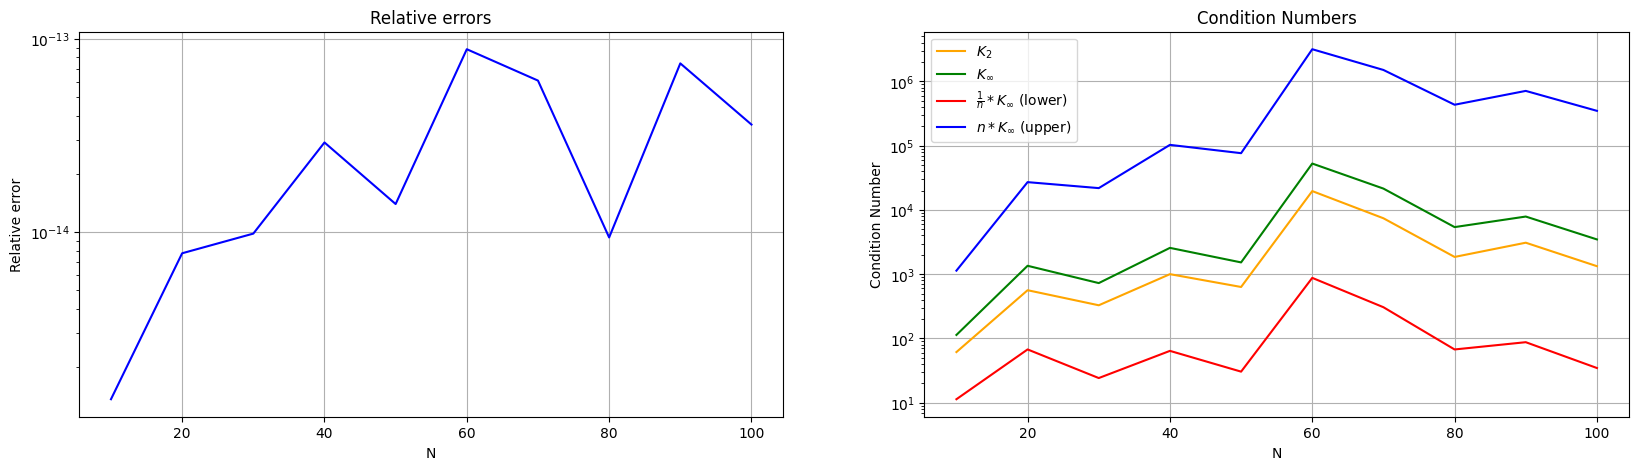

In [33]:
numbers = [*range(10, 110, 10)]
report_results(numbers, "random")

Here, as the matrix is random, we don't have a monotone growth of condition number with respect to the matrix since it repeatedly changes.
Since it does not appears linear in logscale it means it is not ill-conditioned.

#### 1.2.2) Vandermonde matrix

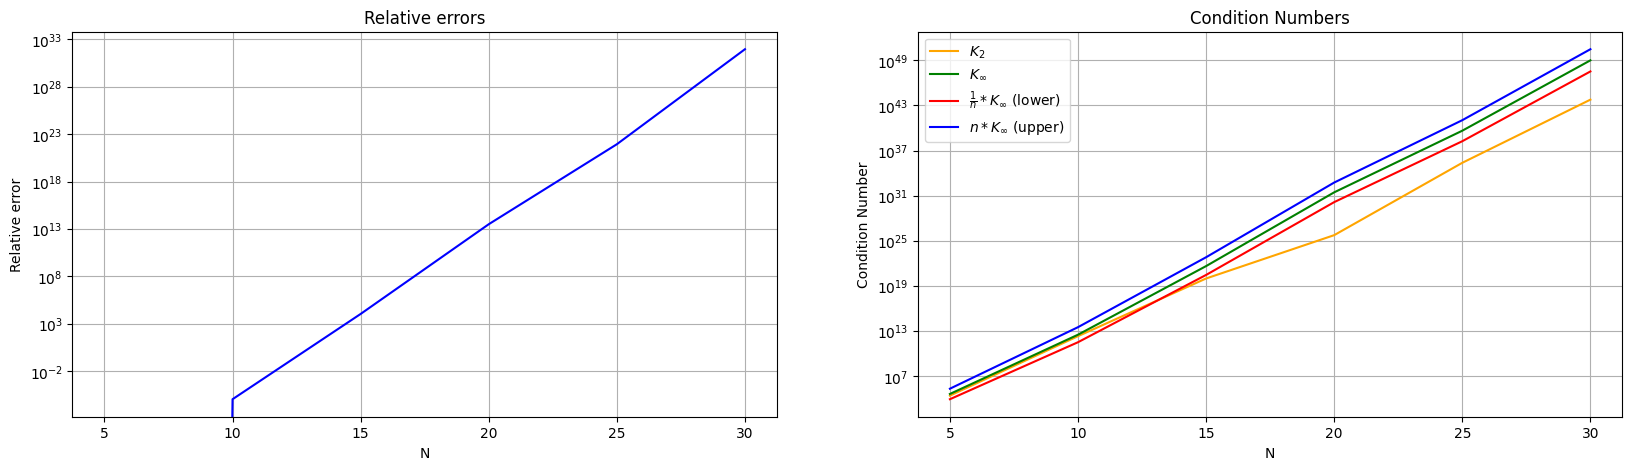

In [34]:
numbers = [*range(5, 35, 5)]
report_results(numbers, "vander")

As we can see, the $K_2$ doesn't respect the constraints, going under the minimum. That should be due to the numerical instability of the vandermonde matrix with high numbers ($N>15$).
Since it appears linear in logscale it means it is ill-conditioned.

#### 1.2.3) Hilbert matrix

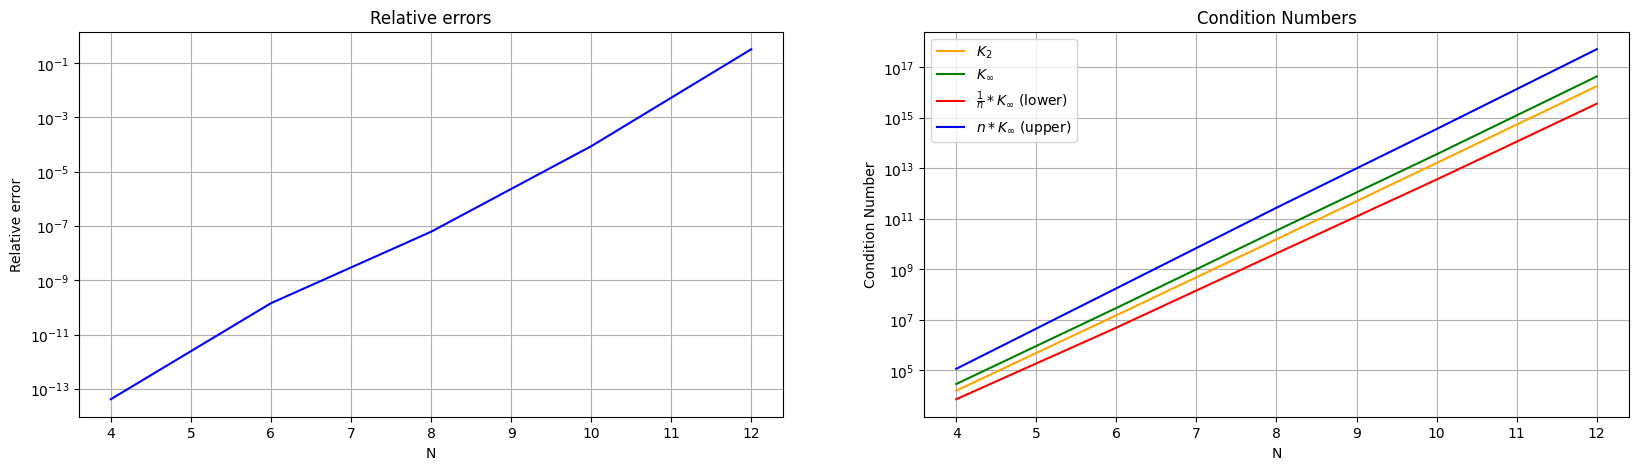

In [35]:
numbers = [*range(4, 14, 2)]
report_results(numbers, "hilbert")

Since it appears linear in logscale it means it is ill-conditioned.

## 2) Floating point arithmetic

### 2.1) The Machine epsilon $\epsilon$ is defined as the smallest floating point number such that it holds: $fl(1 + \epsilon) > 1$. Compute $\epsilon$. 

In [36]:
eps = 1.0

while 1.0 + eps > 1.0:
    eps /= 2.0
print(f"The smallest epsilon is {eps}")
print(f"1 + {eps} = {1.0+eps}")

The smallest epsilon is 1.1102230246251565e-16
1 + 1.1102230246251565e-16 = 1.0


### 2.2) Let’s consider the sequence $a_n = (1 + \frac{1}{n})^n$. It is well known that: $\lim_{n \to \infty} a_n = e$, where $e$ is the Nepero number. Choose diﬀerent values for $n$, compute $a_n$ and compare it to the real value of the Nepero number. What happens if you choose a large value of $n$?

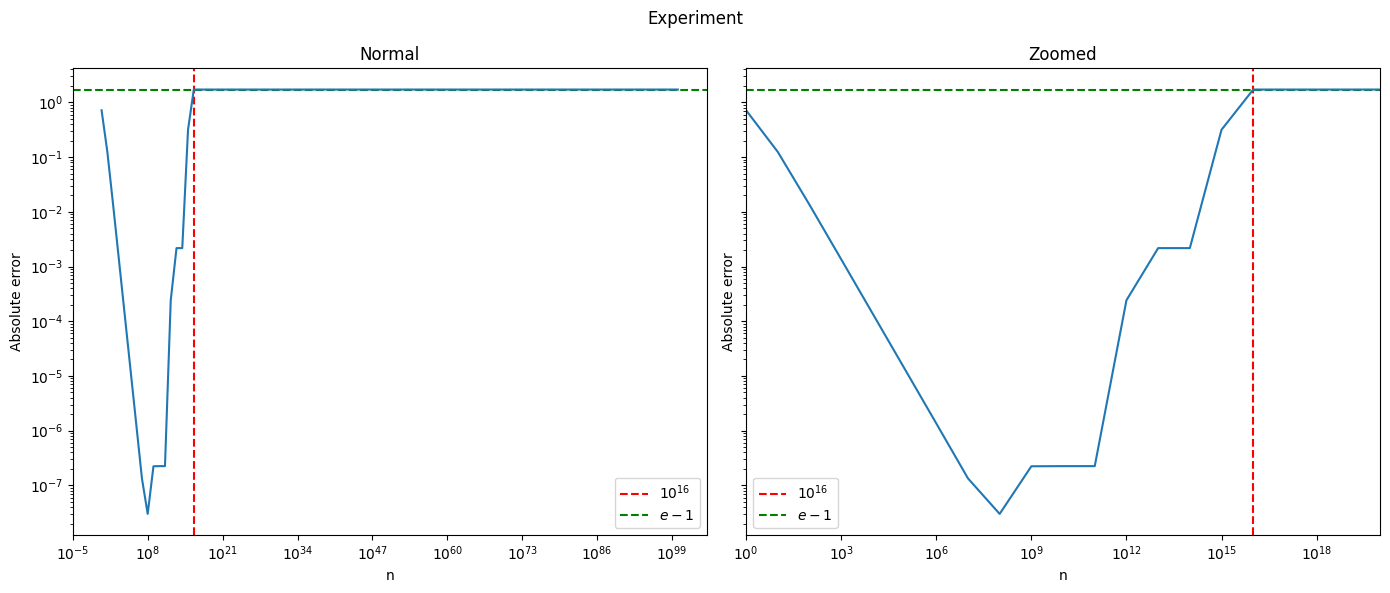

In [37]:
computed_e = []
real_e = np.exp(1)
n = 1
n_range = []

while n < 10e100:
    computed_e.append((1 + 1/n)**n)
    n_range.append(n)
    n *= 10

absolute_error = [abs(e - real_e) for e in computed_e]

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("Experiment")

axs[0].set_title("Normal")
axs[0].set_xlabel('n')
axs[0].set_ylabel('Absolute error')
axs[0].axvline(x=10**16, color='r', linestyle='--', label=r'$10^{16}$')
axs[0].axhline(y=np.e-1, color='g', linestyle='--', label=r'$e-1$')
axs[0].plot(n_range, absolute_error)
axs[0].set_xscale('log')  
axs[0].set_yscale('log')  
axs[0].legend()

axs[1].set_title("Zoomed")
axs[1].set_xlabel('n')
axs[1].set_ylabel('Absolute error')
axs[1].axvline(x=10**16, color='r', linestyle='--', label=r'$10^{16}$')
axs[1].axhline(y=np.e-1, color='g', linestyle='--', label=r'$e-1$')
axs[1].plot(n_range, absolute_error)
axs[1].set_xscale('log') 
axs[1].set_yscale('log') 
axs[1].set_xlim(1e0, 1e20) 
axs[1].legend()

plt.tight_layout()
plt.show()

**This happens because $a_n = 1 + \frac{1}{n}=1$ when when $\frac{1}{n} < \epsilon$  (at approximately $n=10^{16}$)  $\quad \rightarrow \quad$ in fact the absolute error $|e - a_n|$ is exactly $e-1$**

### 2.3) Let’s consider the matrices:

$$
A = \begin{bmatrix} 4 & 2 \\ 1 & 3 \end{bmatrix} \quad B = \begin{bmatrix} 4 & 2 \\ 2 & 1 \end{bmatrix}
$$

Compute the rank of $A$ and $B$ and their eigenvalues. Are $A$ and $B$ full-rank matrices? Can you infer some relationship between the values of the eigenvalues and the full-rank condition? Please, corroborate your deduction with other examples. 
*Tips:* Please, have a look at `np.linalg`.

In [38]:
A = np.array([[4, 2], [1, 3]])
B = np.array([[4, 2], [2, 1]])

# Rank of matrices A and B
rank_A = np.linalg.matrix_rank(A); print(f"Rank(A)={rank_A}")
rank_B = np.linalg.matrix_rank(B); print(f"Rank(B)={rank_B}")

# Eigenvalues of matrices A and B
eigenvalues_A = np.linalg.eigvals(A); print(f"The eigenvalues of A are {eigenvalues_A}")
eigenvalues_B = np.linalg.eigvals(B); print(f"The eigenvalues of B are {eigenvalues_B}")

Rank(A)=2
Rank(B)=1
The eigenvalues of A are [5. 2.]
The eigenvalues of B are [5. 0.]


- A is full-rank and doesn't have a 0 among the eigenvalues
- B is not full-rank and has a 0 among the eigenvalues

**A square matrix is full rank $\iff$ all of its eigenvalues are non-zero.**

In order to prove that we provide 2 other set of examples:

In [39]:
# Example 1
A = np.array([[3, 1], [2, 4]])
B = np.array([[2, 1], [2, 1]])

# Rank of matrices A and B
rank_A = np.linalg.matrix_rank(A); print(f"Rank(A)={rank_A}")
rank_B = np.linalg.matrix_rank(B); print(f"Rank(B)={rank_B}")

# Eigenvalues of matrices A and B
eigenvalues_A = np.linalg.eigvals(A); print(f"The eigenvalues of A are {eigenvalues_A}")
eigenvalues_B = np.linalg.eigvals(B); print(f"The eigenvalues of B are {eigenvalues_B}")


Rank(A)=2
Rank(B)=1
The eigenvalues of A are [2. 5.]
The eigenvalues of B are [3. 0.]


In [40]:
# Example 2
A = np.array([[1, 2], [3, 4]])
B = np.array([[1, 2], [2, 4]])

# Rank of matrices A and B
rank_A = np.linalg.matrix_rank(A); print(f"Rank(A)={rank_A}")
rank_B = np.linalg.matrix_rank(B); print(f"Rank(B)={rank_B}")

# Eigenvalues of matrices A and B
eigenvalues_A = np.linalg.eigvals(A); print(f"The eigenvalues of A are {eigenvalues_A}")
eigenvalues_B = np.linalg.eigvals(B); print(f"The eigenvalues of B are {eigenvalues_B}")

Rank(A)=2
Rank(B)=1
The eigenvalues of A are [-0.37228132  5.37228132]
The eigenvalues of B are [0. 5.]
